In [3]:
import polars as pl
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path
os.sys.path.append('../')
from src.features_hedonic import hedonic_features

In [4]:
def occupancy_features(df, predictions_df):
    
    buckets = {
    1: '1-2',
    2: '1-2',
    3: '3-4',
    4: '3-4',
    5: '5-6',
    6: '5-6',
    7: '7-8',
    8: '7-8'
    }
    # Assign buckets to rows
    df = df.with_columns(
        pl.col('accommodates')
        .replace_strict(buckets, default='9+')
        .alias('bucket'),
        
        (1 - pl.col('availability_365')
        .truediv(365))
        .alias('occupancy_rate')
    )
    # Identify and save whether each row can be compared to ints neighbours
    comp_group = df.group_by(['neighbourhood_cleansed', 'room_type', 'bucket']).agg(pl.len())
    comp_group = comp_group.with_columns(
        pl.when(pl.col('len')>20)
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .alias('local_comp')
    )
    
    # Add comp info back to the dataframe
    df = df.join(comp_group, on=['neighbourhood_cleansed', 'room_type', 'bucket'], how='left').rename({'len': 'local_comp_size'})

    comp_group = df.group_by(['room_type', 'bucket']).agg(pl.len())
    comp_group = comp_group.with_columns(
        pl.when(pl.col('len')>20)
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .alias('citywide_comp')
    )

    df = df.join(comp_group, on=['room_type', 'bucket'], how='left').rename({'len': 'citywide_comp_size'})


    # Add predictions to the dataframe
    df = df.join(predictions_df, on=['id', 'snapshot_date'], how='left')
    
    df = df.with_columns(
        (pl.col('predicted_value') - pl.col('price'))
        .alias('value_gap')
    )
    
    df = df.with_columns(
        
        (pl.col('value_gap')
        .rank(method='average', descending=False)
        .over(['room_type', 'bucket']) / pl.col('citywide_comp_size'))
        .alias('citywide_percentile_rank'),
        
        (pl.col('value_gap')
        .rank(method='average', descending=False)
        .over(['neighbourhood_cleansed', 'room_type', 'bucket']) / pl.col('local_comp_size'))
        .alias('local_percentile_rank')
    )
    
    df = df.with_columns(
        
        pl.when(pl.col('citywide_comp') == 0)
            .then(pl.lit(0.0))
            .otherwise(pl.col('citywide_percentile_rank'))
            .alias('citywide_percentile_rank'),
        
        pl.when(pl.col('local_comp') == 0)
            .then(pl.lit(0.0))
            .otherwise(pl.col('local_percentile_rank'))
            .alias('local_percentile_rank')
    )
        
    return df

In [5]:
load_dotenv()
LISTINGS_DATA = os.getenv('CONCAT_LISTINGS_PATH')
CALENDER_DATA = os.getenv('CONCAT_CALENDER_PATH')
PRED_DATA = os.getenv('PRED_PATH')

ldf = pl.read_parquet(LISTINGS_DATA)
predictions = pl.read_parquet(PRED_DATA)

In [6]:
ldf = hedonic_features(ldf)
ldf.shape

(11623, 145)

In [7]:
ldf = occupancy_features(ldf, predictions)
ldf.shape

(11623, 155)

In [8]:
target_col = 'availability_30'

corr_df = ldf.select(
    pl.corr(target_col, pl.col(name)).alias(name)
    for name, dtype in ldf.schema.items()
    if dtype.is_numeric()
)

corr_df

scrape_id,host_id,host_profile_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,price_quote_total_price,price_quote_price_per_night,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,…,has_city_skyline_view,has_tv,room_type_hotel_room,room_type_private_room,room_type_shared_room,neighbourhood_bijlmer-centrum,neighbourhood_bijlmer-oost,neighbourhood_bos_en_lommer,neighbourhood_buitenveldert_-_zuidas,neighbourhood_centrum-oost,neighbourhood_de_aker_-_nieuw_sloten,neighbourhood_de_baarsjes_-_oud-west,neighbourhood_de_pijp_-_rivierenbuurt,neighbourhood_gaasperdam_-_driemond,neighbourhood_geuzenveld_-_slotermeer,neighbourhood_ijburg_-_zeeburgereiland,neighbourhood_noord-oost,neighbourhood_noord-west,neighbourhood_oostelijk_havengebied_-_indische_buurt,neighbourhood_osdorp,neighbourhood_oud-noord,neighbourhood_oud-oost,neighbourhood_slotervaart,neighbourhood_watergraafsmeer,neighbourhood_westerpark,neighbourhood_zuid,property_type_hotel,property_type_unique,occupancy_rate,local_comp_size,local_comp,citywide_comp_size,citywide_comp,predicted_value,value_gap,citywide_percentile_rank,local_percentile_rank
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.09161,0.017108,-0.006106,-0.180963,-0.010593,-0.079905,0.013113,-0.023652,0.103139,0.079892,NaN,-0.052375,-0.02458,-0.046148,-0.037201,-0.103888,-0.053833,0.056969,0.024798,0.069572,-0.014754,0.018848,-0.002745,-0.006282,0.018847,0.018847,-0.017735,0.018848,NaN,1.0,0.927465,0.857508,0.484685,-0.001692,0.042498,0.024022,0.704962,…,0.009109,0.018509,0.035616,0.082368,0.045441,0.03095,0.014074,-0.006921,0.045927,0.029103,-0.003271,-0.011542,0.003299,0.014211,0.023494,-0.011473,-0.012396,-0.034638,-0.022411,0.028265,-0.013524,-0.002345,-0.007282,-0.025406,-0.021762,0.027277,0.115552,0.004072,-0.484685,-0.019851,-0.050629,-0.067896,-0.023888,0.01778,-0.055579,-0.219429,-0.219065


In [9]:
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

result = ldf.select(
    [pl.col("reviews_per_month").quantile(q).alias(f"q_{q}") for q in quantiles]
)

<Axes: xlabel='reviews_per_month', ylabel='Count'>

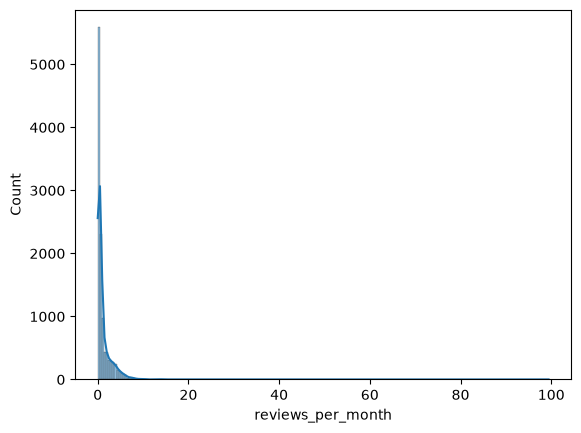

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
df = ldf.to_pandas()
sns.histplot(df, x='reviews_per_month', kde=True)

In [21]:
ldf['id' == 1551647967619599000]['snapshot_date']

snapshot_date
str
"""2026-06-15"""
